In [1]:
import os
from pathlib import Path
from torch_geometric.datasets import QM9

DATA_ROOT = Path.cwd().parent / "data" / "QM9" 

dataset = QM9(DATA_ROOT)

/opt/anaconda3/envs/equi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Extracting /Users/orinpechler/Documents/Universiteit van Amsterdam/Master Year 1/Period 5/Deep Learning II/drifting-experiments/data/QM9/raw/qm9.zip
/opt/anaconda3/envs/equi/lib/python3.11/site-packages/torch_geometric/data/dataset.py:115: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  self._process()


In [328]:
import torch
from torch import nn

class DummyModel(nn.Module):
    def __init__(self, num_nodes: int, num_atom_types: int = 0):
        super().__init__()
        num_positions = 3
        # Add atom type as target if necessary
        num_targets = num_positions + num_atom_types
        self.hidden_layer = nn.Linear(num_nodes * num_targets, 1000)
        self.hidden_layer_2 = nn.Linear(1000, 1000)
        self.layer = nn.Linear(
            1000, num_nodes * num_targets
        )

    def forward(self, noise: torch.Tensor):
        return self.layer(self.hidden_layer_2(self.hidden_layer(noise)))

In [3]:
from torch_geometric.nn import global_mean_pool

def get_sorted_mols(gen_mols, real_mol):
    dists = torch.cdist(gen_mols, real_mol)
    closest_indices = torch.argsort(dists, dim=0)
    return gen_mols[closest_indices], closest_indices

def center_positions_per_mol(
    pos: torch.Tensor, batch_vec: torch.Tensor = None
) -> torch.Tensor:
    """Zero-center coordinates independently for each graph in a batch."""
    if batch_vec is None:
        return pos - pos.mean(dim=0, keepdim=True)
    com = global_mean_pool(pos, batch_vec)  # [G, 3]
    return pos - com[batch_vec]

In [137]:
import torch
import torch.nn.functional as F

NUM_ITERS = 3000
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
print(f"Real molecule positions shape: {real_pos.shape}")

real_types = real_mol.real_atom_types
print(f"Real molecule atom types shape: {real_types.shape}")

Number of nodes: 5
Real molecule positions shape: torch.Size([5, 3])
Real molecule atom types shape: torch.Size([5, 5])


In [7]:
import torch


def sphere_normalize(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Normalize each position independently onto S^3.
    """
    return x / x.norm(dim=-1, keepdim=True).clamp_min(eps)


def probs_to_sphere(p: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Map simplex probabilities to positive orthant of the sphere:
        phi(p) = sqrt(p)
    p: [N_atoms, 5], sum=1 along last dim
    Returns x in S^3_+ at each position: [N_atoms, 5]
    """
    p = p.clamp_min(eps)
    p = p / p.sum(dim=-1, keepdim=True).clamp_min(eps)
    x = torch.sqrt(p)
    return sphere_normalize(x, eps)


def sphere_to_probs(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Inverse map of phi on S^3_+:
        p_i = x_i^2
    x: [N_atoms, 5]
    returns probs: [N_atoms, 5]
    """
    x = sphere_normalize(x, eps).clamp_min(0.0)
    p = x.pow(2)
    return p / p.sum(dim=-1, keepdim=True).clamp_min(eps)


def sphere_project_tangent(x: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    """
    Project v onto tangent space at x, positionwise.
    x, v: [N_atoms, 5]
    """
    return v - (x * v).sum(dim=-1, keepdim=True) * x


def product_tangent_norm(v: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Product metric norm:
        ||v||_g^2 = sum_l ||v_l||_2^2
    v: [N_atoms, 5]
    returns: [N_atoms, 1]
    """
    return torch.clamp(torch.norm(v, dim=-1, keepdim=True), min=1e-8)


def sphere_log(x: torch.Tensor, y: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Positionwise sphere log map on S^3.

    x, y: [N_atoms, 5], each position normalized.
    returns: [N_atoms, 5], tangent at x
    """
    x = sphere_normalize(x, eps)
    y = sphere_normalize(y, eps)

    dot = (x * y).sum(dim=-1, keepdim=True).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
    theta = torch.acos(dot)  # [..., L, 1]

    u = y - dot * x
    u_norm = u.norm(dim=-1, keepdim=True)

    scale = theta / u_norm.clamp_min(eps)
    out = scale * u

    small = theta < 1e-5
    first_order = sphere_project_tangent(x, y - x)
    out = torch.where(small, first_order, out)
    return sphere_project_tangent(x, out)


def sphere_exp(x: torch.Tensor, v: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Positionwise sphere exp map on S^3.

    x: [N_atoms, 5] normalized
    v: [N_atoms, 5] tangent at x
    returns: [N_atoms, 5] on sphere
    """
    x = sphere_normalize(x, eps)
    v = sphere_project_tangent(x, v)

    v_norm = v.norm(dim=-1, keepdim=True)
    direction = v / v_norm.clamp_min(eps)

    out = torch.cos(v_norm) * x + torch.sin(v_norm) * direction
    approx = sphere_normalize(x + v, eps)

    out = torch.where(v_norm < 1e-5, approx, out)
    return sphere_normalize(out, eps)


def geodesic_distance(
    x: torch.Tensor,  # [Num_mol, max_atoms, 5]
    y: torch.Tensor,  # [Num_mol, max_atoms, 5]
    eps: float = 1e-8,
) -> torch.Tensor:
    x = sphere_normalize(x, eps)
    y = sphere_normalize(y, eps)

    dot = (x * y).sum(dim=-1).clamp(-1.0 + 1e-7, 1.0 - 1e-7) 
    return torch.acos(dot)  # [N_mol, max_atoms]

In [11]:

def sample_pos_noise(n_gen_mols: int, num_nodes: int):
    """Sample and center position noise for"""
    pos_noise = torch.randn((n_gen_mols * num_nodes, 3))
    batch_vec = torch.arange(n_gen_mols).repeat_interleave(num_nodes)
    pos_noise = center_positions_per_mol(pos_noise, batch_vec)
    pos_noise = pos_noise / pos_noise.std(dim=0)
    return pos_noise


def sample_type_noise(n_gen_mols: int, num_nodes: int, num_atom_types: int):
    """Sample random noise as embedding for atom types"""
    type_noise = torch.randn((n_gen_mols * num_nodes, num_atom_types))
    return type_noise


In [314]:
import matplotlib.pyplot as plt
import torch

def visualize_both_molecules(gen_mol: torch.Tensor, real_mol: torch.Tensor):
    gen_mol = gen_mol.view(-1, 3).detach().cpu().numpy()
    real_mol = real_mol.view(-1, 3).detach().cpu().numpy()
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(gen_mol[:, 0], gen_mol[:, 1], gen_mol[:, 2], color='red', label='Generated Molecule')
    ax1.set_title('Generated Molecule')
    ax1.legend()
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(real_mol[:, 0], real_mol[:, 1], real_mol[:, 2], color='blue', label='Real Molecule')
    ax2.set_title('Real Molecule')
    ax2.legend()
    plt.show()

def visualize_both_molecules_with_atom_types(
    gen_pos: torch.Tensor,
    gen_types: torch.Tensor,
    real_pos: torch.Tensor,
    real_types: torch.Tensor,
    mol_idx: int = 0,
):
    # Select one molecule from batched positions: [Num_mol, Num_atoms, 3]
    if gen_pos.dim() == 3:
        gen_pos = gen_pos[mol_idx]
    if real_pos.dim() == 3:
        real_pos = real_pos[mol_idx]

    # Select one molecule from batched type vectors: [Num_mol, Num_atoms, Num_types]
    if gen_types.dim() == 3:
        gen_types = gen_types[mol_idx]
    if real_types.dim() == 3:
        real_types = real_types[mol_idx]

    # Select one molecule from batched type labels: [Num_mol, Num_atoms]
    if gen_types.dim() == 2 and gen_types.shape[0] != gen_pos.shape[0]:
        gen_types = gen_types[mol_idx]
    if real_types.dim() == 2 and real_types.shape[0] != real_pos.shape[0]:
        real_types = real_types[mol_idx]

    # Convert one-hot/prob/type vectors [Num_atoms, Num_types] to labels [Num_atoms]
    if gen_types.dim() == 2:
        gen_types = gen_types.argmax(dim=-1)
    if real_types.dim() == 2:
        real_types = real_types.argmax(dim=-1)

    gen_pos_np = gen_pos.detach().cpu().numpy()
    real_pos_np = real_pos.detach().cpu().numpy()

    gen_types_cpu = gen_types.detach().cpu().long()
    real_types_cpu = real_types.detach().cpu().long()

    fig = plt.figure(figsize=(12, 6))

    ax1 = fig.add_subplot(121, projection="3d")
    for atom_type in torch.unique(gen_types_cpu):
        mask = (gen_types_cpu == atom_type).numpy()
        ax1.scatter(
            gen_pos_np[mask, 0],
            gen_pos_np[mask, 1],
            gen_pos_np[mask, 2],
            label=f"Atom Type {int(atom_type.item())}",
        )
    ax1.set_title("Generated Molecule")
    ax1.legend()

    ax2 = fig.add_subplot(122, projection="3d")
    for atom_type in torch.unique(real_types_cpu):
        mask = (real_types_cpu == atom_type).numpy()
        ax2.scatter(
            real_pos_np[mask, 0],
            real_pos_np[mask, 1],
            real_pos_np[mask, 2],
            label=f"Atom Type {int(atom_type.item())}",
        )
    ax2.set_title("Real Molecule")
    ax2.legend()

    plt.show()

def plot_loss(loss_list):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(loss_list)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title("Training Loss")
    ax.grid(True, alpha=0.3)
    plt.show()

# One Gen Mol and One Real Mol WITH Atom Types - MLP

In [119]:
# Sample noise once but for multiple molecules
# as the real molecules
# This is the logic in sample noise above
pos_noise = torch.randn((real_mol.num_nodes, 3))
pos_noise = pos_noise - pos_noise.mean(dim=0)
print(f"Position noise shape: {pos_noise.shape}")

# We sample random noise as embedding for atom types
type_noise = torch.randn((real_mol.num_nodes, 5))
print(f"Combined noise shape: {type_noise.shape}")
print()

Position noise shape: torch.Size([5, 3])
Combined noise shape: torch.Size([5, 5])



In [120]:
combined_noise = torch.cat([pos_noise, type_noise], dim=1).flatten()
print(f"Combined noise shape: {combined_noise.shape}")

Combined noise shape: torch.Size([40])


In [71]:
import torch
from torch import nn
from torch_geometric.nn import MessagePassing

class TypeGCN(MessagePassing):
    propagate_type = {"type_feat": torch.Tensor, "edge_attr": torch.Tensor}

    def __init__(
        self, hidden_nf: int, attention: bool = True, aggr_type: str = "sum"
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2
        self.message_mlp = nn.Sequential(
            nn.Linear(in_message_dim, in_message_dim),
            nn.SiLU(),
            nn.Linear(in_message_dim, hidden_nf),
        )

        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_nf * 2, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
        )

        self.attention = attention
        if self.attention:
            self.att_mlp = nn.Sequential(
                nn.Linear(hidden_nf, 1),
                nn.Sigmoid(),
            )

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor
    ) -> torch.Tensor:
        input_tensor = torch.cat(
            [type_feat_i, type_feat_j, edge_attr],
            dim=-1,
        )
        out = self.message_mlp(input_tensor)

        if self.attention:
            att_val = self.att_mlp(out)
            return out * att_val

        return out

    def update(self, aggr_out: torch.Tensor, type_feat: torch.Tensor) -> torch.Tensor:
        out = torch.cat([aggr_out, type_feat], dim=-1)
        return type_feat + self.update_mlp(out)

    def forward(
        self, type_feat: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor
    ) -> torch.Tensor:
        return self.propagate(
            edge_index, type_feat=type_feat, edge_attr=edge_attr
        )


class PosGCN(MessagePassing):
    propagate_type = {
        "type_feat": torch.Tensor,
        "scaled_dir_vector": torch.Tensor,
        "edge_attr": torch.Tensor,
    }

    def __init__(
        self,
        hidden_nf: int,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2

        layer = nn.Linear(hidden_nf, 1, bias=False)
        torch.nn.init.xavier_uniform_(layer.weight, gain=0.001)

        self.coord_mlp = nn.Sequential(
            nn.Linear(in_message_dim, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
            nn.SiLU(),
            layer,
        )

        self.tanh_coord_updates = tanh_coord_updates
        self.coords_range = coords_range

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        input_tensor = torch.cat([type_feat_i, type_feat_j, edge_attr], dim=-1)
        weight = self.coord_mlp(input_tensor)
        if self.tanh_coord_updates:
            weight = torch.tanh(weight) * self.coords_range
        return scaled_dir_vector * weight

    def forward(
        self,
        pos: torch.Tensor,
        type_feat: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        delta = self.propagate(
            edge_index,
            type_feat=type_feat,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )
        return pos + delta


class EquivariantBlock(nn.Module):
    def __init__(
        self,
        hidden_nf: int,
        n_layers: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()

        self.type_update = nn.ModuleList(
            [
                TypeGCN(hidden_nf, attention=attention, aggr_type=aggr_type)
                for _ in range(n_layers)
            ]
        )

        self.coord_update = PosGCN(
            hidden_nf,
            tanh_coord_updates=tanh_coord_updates,
            coords_range=coords_range,
            aggr_type=aggr_type,
        )

    def forward(
        self,
        type_feat: torch.Tensor,
        pos: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        for type_gcn in self.type_update:
            type_feat = type_gcn(
                type_feat=type_feat,
                edge_index=edge_index,
                edge_attr=edge_attr
            )

        pos = self.coord_update(
            pos=pos,
            type_feat=type_feat,
            edge_index=edge_index,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )

        return type_feat, pos

def compute_edge_properties(
    pos: torch.Tensor, edge_index: torch.Tensor, norm_constant: float = 1.0
) -> tuple[torch.Tensor, torch.Tensor]:
    src, dst = edge_index
    dist = pos[src] - pos[dst]
    squared_norm = dist.pow(2).sum(dim=-1)
    norm = squared_norm.sqrt()
    scaled_dir_vector = dist / (norm.unsqueeze(-1) + norm_constant)
    return squared_norm, scaled_dir_vector

class EGNN(nn.Module):
    def __init__(
        self,
        num_atom_types: int,
        num_blocks: int = 9,
        hidden_nf: int = 256,
        num_layers_per_block: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()
        self.type_embedding = nn.Linear(num_atom_types, hidden_nf)
        self.type_embedding_out = nn.Linear(hidden_nf, num_atom_types)
        self.blocks = nn.ModuleList(
            [
                EquivariantBlock(
                    hidden_nf,
                    n_layers=num_layers_per_block,
                    attention=attention,
                    tanh_coord_updates=tanh_coord_updates,
                    coords_range=coords_range,
                    aggr_type=aggr_type,
                )
                for _ in range(num_blocks)
            ]
        )

    def forward(
        self,
        pos_noise: torch.Tensor,
        type_noise: torch.Tensor,
        edge_index: torch.Tensor,
        return_change_in_pos: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        gen_feats = self.type_embedding(type_noise)
        gen_pos = pos_noise
        initial_squared_norm, _ = compute_edge_properties(gen_pos, edge_index)

        pos_list = []
        if return_change_in_pos:
            pos_list.append(gen_pos.clone())

        for block in self.blocks:
            squared_norm, scaled_dir_vector = compute_edge_properties(gen_pos, edge_index)
            edge_attr = torch.cat(
                [initial_squared_norm.unsqueeze(-1), squared_norm.unsqueeze(-1)],
                dim=-1,
            )
            gen_feats, gen_pos = block(
                type_feat=gen_feats,
                pos=gen_pos,
                edge_index=edge_index,
                scaled_dir_vector=scaled_dir_vector,
                edge_attr=edge_attr,
            )
            if return_change_in_pos:
                pos_list.append(gen_pos.clone())

        gen_types = self.type_embedding_out(gen_feats)

        if return_change_in_pos:
            return gen_pos, gen_types, pos_list
        return gen_pos, gen_types

Iter 99: Loss = 1.2264244556427002
euclidean distance:  tensor(0.1803, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(1.0461, grad_fn=<MeanBackward0>)
Iter 199: Loss = 0.8605848550796509
euclidean distance:  tensor(0.0091, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.8515, grad_fn=<MeanBackward0>)
Iter 299: Loss = 0.6777136921882629
euclidean distance:  tensor(0.0005, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.6773, grad_fn=<MeanBackward0>)
Iter 399: Loss = 0.5350275635719299
euclidean distance:  tensor(2.2980e-05, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.5350, grad_fn=<MeanBackward0>)
Iter 499: Loss = 0.4258926510810852
euclidean distance:  tensor(1.1565e-06, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.4259, grad_fn=<MeanBackward0>)
Iter 599: Loss = 0.34465208649635315
euclidean distance:  tensor(5.8203e-08, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.3447, grad_fn=<MeanBackward0>)
Iter 699: Loss = 0.2844490110874176
eucl

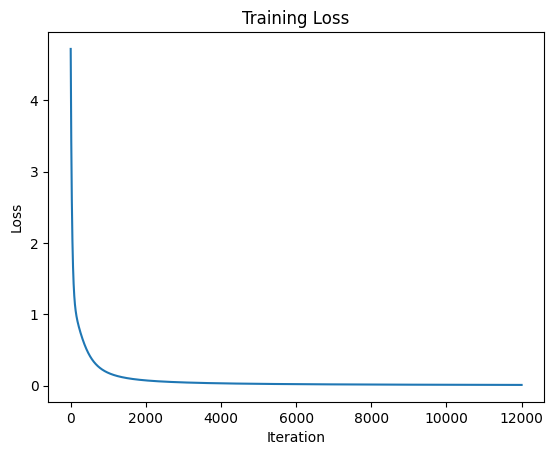

In [121]:
# Instantiate model and optimizer
model = DummyModel(
    num_nodes=real_mol.num_nodes, num_atom_types=5
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

TEMP = 1

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_mol = model(combined_noise)
    gen_mol = gen_mol.reshape(real_mol.num_nodes, -1)
    gen_pos, gen_types = torch.split(gen_mol, [3, 5], dim=1)
    gen_types_prob = F.softmax(gen_types, dim=-1)
    gen_types_sphere = probs_to_sphere(gen_types_prob, eps=1e-8)

    V_pos = real_pos - gen_pos
    V_types = sphere_log(gen_types_sphere, real_types, eps=1e-8)

    target_pos = (gen_pos + V_pos).detach()
    target_types = sphere_exp(gen_types_sphere, V_types, eps=1e-8).detach()

    pos_distance = (gen_pos - target_pos).pow(2).sum(dim=-1)
    types_distance = (geodesic_distance(gen_types_sphere, target_types, eps=1e-8)).pow(2)
    total_distance = pos_distance + types_distance

    loss = total_distance.mean()

    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")
        print("euclidean distance: ", pos_distance.mean())
        print("spherical_distance: ", types_distance.mean())

plot_loss(loss_list)

tensor([1., 0., 0., 0., 0.])
tensor([1., 0., 0., 0., 0.])


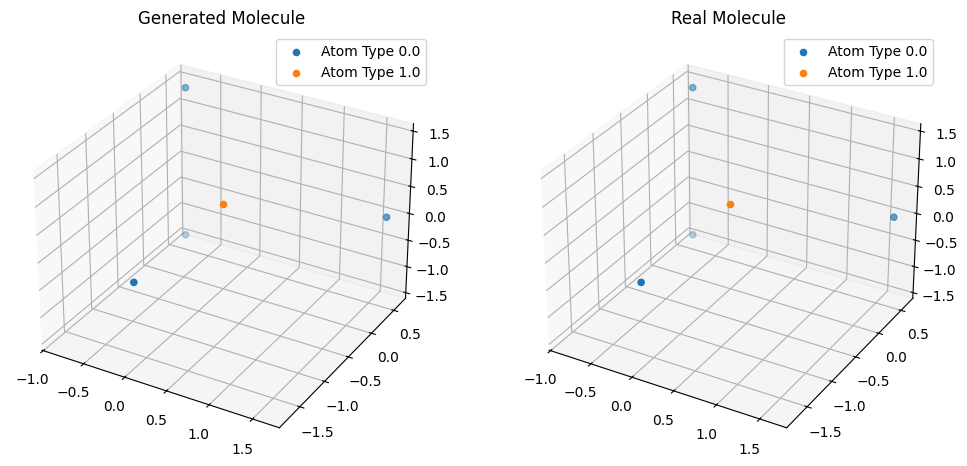

In [122]:
gen_mol = model(combined_noise)
gen_mol = gen_mol.reshape(real_mol.num_nodes, -1)
gen_pos, gen_types = torch.split(gen_mol, [3, 5], dim=1)
gen_types_prob = F.softmax(gen_types, dim=-1)
gen_types_sphere = probs_to_sphere(gen_types_prob, eps=1e-8)
gen_types_prob = sphere_to_probs(gen_types_sphere, eps=1e-8)

gen_types_argmax = gen_types_prob.argmax(dim=1).float()
real_types_argmax = real_types.argmax(dim=1).float()

print(real_types_argmax)
print(gen_types_argmax)

visualize_both_molecules_with_atom_types(
    gen_pos, gen_types_argmax, real_pos, real_types_argmax
)

# One Gen Mol and One Real Mol WITH Atom Types - EGNN

In [123]:
# Sample noise once but for multiple molecules
# as the real molecules
# This is the logic in sample noise above
pos_noise = torch.randn((real_mol.num_nodes, 3))
pos_noise = pos_noise - pos_noise.mean(dim=0)
print(f"Position noise shape: {pos_noise.shape}")

# We sample random noise as embedding for atom types
type_noise = torch.randn((real_mol.num_nodes, 5))
print(f"Combined noise shape: {type_noise.shape}")
print()

Position noise shape: torch.Size([5, 3])
Combined noise shape: torch.Size([5, 5])



In [125]:

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 32
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "sum"

# Instantiate model and optimizer
# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

dense_edge_index = real_mol.dense_edge_index

NUM_ITERS = 8000

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    # Instantiate model and optimizer

    gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)
    gen_pos = gen_pos - gen_pos.mean(dim=0)

    gen_types_prob = F.softmax(gen_types, dim=-1)
    gen_types_sphere = probs_to_sphere(gen_types_prob, eps=1e-8)

    V_pos = real_pos - gen_pos
    V_types = sphere_log(gen_types_sphere, real_types, eps=1e-8)

    target_pos = (gen_pos + V_pos).detach()
    target_types = sphere_exp(gen_types_sphere, V_types, eps=1e-8).detach()

    pos_distance = (gen_pos - target_pos).pow(2).sum(dim=-1)
    types_distance = (geodesic_distance(gen_types_sphere, target_types, eps=1e-8)).pow(2)
    total_distance = pos_distance + types_distance

    loss = total_distance.mean()

    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")
        print("euclidean distance: ", pos_distance.mean())
        print("spherical_distance: ", types_distance.mean())


Iter 99: Loss = 3.758711576461792
euclidean distance:  tensor(2.6896, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(1.0691, grad_fn=<MeanBackward0>)
Iter 199: Loss = 3.4488937854766846
euclidean distance:  tensor(2.5480, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.9009, grad_fn=<MeanBackward0>)
Iter 299: Loss = 3.059164524078369
euclidean distance:  tensor(2.3683, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.6908, grad_fn=<MeanBackward0>)
Iter 399: Loss = 2.6777548789978027
euclidean distance:  tensor(2.1346, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.5432, grad_fn=<MeanBackward0>)
Iter 499: Loss = 2.3937294483184814
euclidean distance:  tensor(1.9011, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.4926, grad_fn=<MeanBackward0>)
Iter 599: Loss = 2.139767646789551
euclidean distance:  tensor(1.6652, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.4745, grad_fn=<MeanBackward0>)
Iter 699: Loss = 1.8559596538543701
euclidean distance: 

tensor([1., 0., 0., 0., 0.])
tensor([1., 0., 0., 0., 0.])


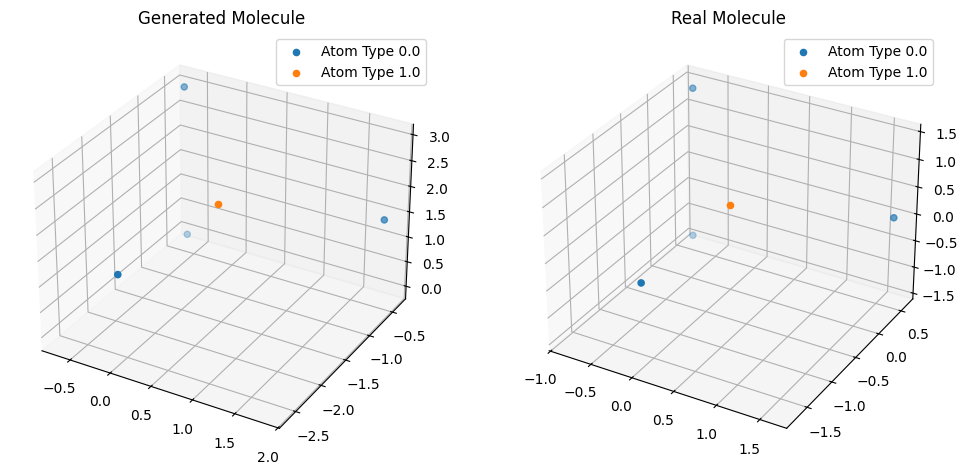

In [126]:
gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)
gen_types_prob = F.softmax(gen_types, dim=-1)
gen_types_sphere = probs_to_sphere(gen_types_prob, eps=1e-8)
gen_types_prob = sphere_to_probs(gen_types_sphere, eps=1e-8)

gen_types_argmax = gen_types_prob.argmax(dim=1).float()
real_types_argmax = real_types.argmax(dim=1).float()

print(real_types_argmax)
print(gen_types_argmax)

visualize_both_molecules_with_atom_types(
    gen_pos, gen_types_argmax, real_pos, real_types_argmax
)

# Multiple Gen Mol from multiple noise sampled once and One Real Mol WITH Atom Types - MLP

In [340]:

for i in range(1000000):
    real_mol = dataset[i]
    if real_mol.pos.shape[0] == 7:
        print(i)

8
10
16
33
105
167
168
169
171
312
315
475
481
763
764
776
812
814
3765
3830


IndexError: range object index out of range

In [343]:
indices = [8, 10, 16, 33, 105, 167, 168, 169, 171, 312, 315, 475, 481, 763, 764, 776, 812, 814, 3765, 3830]

In [344]:
real_mols = dataset[indices]

real_positions = real_mols.pos.reshape(20, 7, 3)
real_types = real_mols.real_atom_types.reshape(20, 7, 5)
print(real_positions.shape)
print(real_types.shape)
real_positions = real_positions - real_positions.mean(dim=1, keepdim=True)

torch.Size([20, 7, 3])
torch.Size([20, 7, 5])


In [ ]:
# real_pos = real_pos.unsqueeze(0)
# real_types = real_types.unsqueeze(0)
# print(real_pos.shape)
# print(real_types.shape)

torch.Size([1, 5, 3])
torch.Size([1, 5, 5])


In [332]:
def compute_aligning_drift_loss(
    gen_pos: torch.Tensor,
    real_pos: torch.Tensor,
    gen_types_sphere: torch.Tensor,
    real_types: torch.Tensor,
    sigma: float = 1.0,
    eps: float = 1e-8
) -> tuple[torch.Tensor, dict[str, float]]:
    """
    Drifting field loss directly on 3D molecules by aligning the generated molecules with the real ones.
    Assumes that x_gen_sphere is already mapped to the spherical space

    Returns (loss, stats) where stats is a flat dict of float diagnostics safe to
    pass directly to self.log(). Raises TrainingDivergedException on non-finite loss.
    """
    real_types = real_types.float()

    N_gen = gen_pos.shape[0]
    N_real = real_pos.shape[0]

    # Distances of shape [N_gen, N_real/N_gen] and Differences of shape [N_gen, N_real/N_gen, N_atoms, 3/5]
    posit_dist_pos, posit_diff_pos = _pairwise_geodesic_distance_and_log(gen_pos, real_pos, "euclidean", eps)
    posit_dist_neg, posit_diff_neg = _pairwise_geodesic_distance_and_log(gen_pos, gen_pos, "euclidean", eps)

    types_dist_pos, types_diff_pos = _pairwise_geodesic_distance_and_log(gen_types_sphere, real_types, "spherical", eps)
    types_dist_neg, types_diff_neg = _pairwise_geodesic_distance_and_log(gen_types_sphere, gen_types_sphere, "spherical", eps)

    # PERHAPS DIVIDE DIST BY SQRT N_ATOMS

    # Ignore self if y_neg is x
    eye = torch.eye(N_gen, device=gen_pos.device, dtype=torch.bool)
    posit_dist_neg = posit_dist_neg.masked_fill(eye, 1e6)
    types_dist_neg = types_dist_neg.masked_fill(eye, 1e6)

    # Calculate kernels
    posit_kernel_pos = torch.exp(-posit_dist_pos / (2 * sigma**2))   # shape [N_gen, N_real]
    posit_kernel_neg = torch.exp(-posit_dist_neg / (2 * sigma**2))   # shape [N_gen, N_real]

    types_kernel_pos = torch.exp(-types_dist_pos / (2 * sigma**2))   # shape [N_gen, N_real]
    types_kernel_neg = torch.exp(-types_dist_neg / (2 * sigma**2))   # shape [N_gen, N_gen]

    # Calculate gradient of kernels towards generated input
    posit_grad_kernel_pos = - (posit_diff_pos * posit_kernel_pos.unsqueeze(-1).unsqueeze(-1)) / (sigma**2)  # shape [N_gen, N_real, N_atoms, 3]
    posit_grad_kernel_neg = - (posit_diff_neg * posit_kernel_neg.unsqueeze(-1).unsqueeze(-1)) / (sigma**2)  # shape [N_gen, N_gen, N_atoms, 3]

    types_grad_kernel_pos = (types_diff_pos * types_kernel_pos.unsqueeze(-1).unsqueeze(-1)) / (sigma**2)    # shape [N_gen, N_real, N_atoms, 5]
    types_grad_kernel_neg = (types_diff_neg * types_kernel_neg.unsqueeze(-1).unsqueeze(-1)) / (sigma**2)    # shape [N_gen, N_gen, N_atoms, 5]

    # Drifting positive direction
    V_posit_pos = posit_grad_kernel_pos.sum(dim=1) / (posit_kernel_pos.sum(dim=1).clamp_min(eps).unsqueeze(-1).unsqueeze(-1))   # shape [N_gen, N_atoms, 3]
    V_posit_neg = posit_grad_kernel_neg.sum(dim=1) / (posit_kernel_neg.sum(dim=1).clamp_min(eps).unsqueeze(-1).unsqueeze(-1))   # shape [N_gen, N_atoms, 3]

    V_types_pos = types_grad_kernel_pos.sum(dim=1) / (types_kernel_pos.sum(dim=1).clamp_min(eps).unsqueeze(-1).unsqueeze(-1))   # shape [N_gen, N_atoms, 5]
    V_types_neg = types_grad_kernel_neg.sum(dim=1) / (types_kernel_neg.sum(dim=1).clamp_min(eps).unsqueeze(-1).unsqueeze(-1))   # shape [N_gen, N_atoms, 5]

    # Calculate drifting fields
    V_posit = V_posit_pos - V_posit_neg
    V_types = V_types_pos - V_types_neg
    V_types = sphere_project_tangent(gen_types_sphere, V_types)

    # PERHAPS HERE ADD SCALING OF DRIFTING FIELD

    # Calculate targets for each 
    target_posit = (gen_pos + V_posit).detach()
    target_types = sphere_exp(gen_types_sphere, V_types, eps).detach()

    # Calculate distances per molecule on each manifold
    molecule_position_dist = ((gen_pos - target_posit) ** 2).sum(dim=-1).sum(dim=-1)    # shape: [N_gen]
    molecule_types_dist = (geodesic_distance(gen_types_sphere, target_types, eps) ** 2).sum(dim=-1) # shape: [N_gen]

    loss = (molecule_position_dist + molecule_types_dist).mean()
    
    return loss, molecule_position_dist, molecule_types_dist


def _pairwise_geodesic_distance_and_log(
        x: torch.Tensor,
        y: torch.Tensor,
        manifold: str = "euclidean",
        eps: float = 1e-8,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Calculates the pairwise distance between atoms for the molecule attributes depending on 
    the specified geodesic distance. Assumed that molecules are aligned.
    Args:
        x: [N_x, N_atoms, z]
        y: [N_y, N_atoms, z]
    """

    if manifold == "euclidean":
        diff = x[:, None, :, :] - y[None, :, :, :]                              # shape: (N_x, N_y, N_atoms, z)
        sq_dist_per_atom = (diff ** 2).sum(dim=-1)                              # shape: (N_x, N_y, N_atoms)

        sq_distances = sq_dist_per_atom.sum(dim=-1)   # shape: (N_x, N_y)
    elif manifold == "spherical":
        x = sphere_normalize(x, eps)
        y = sphere_normalize(y, eps)

        dot = torch.einsum("blc,nlc->bnl", x, y).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        theta = torch.acos(dot)  # [N_x, N_y, N_atoms]

        sq_distances = theta.pow(2).sum(dim=-1).clamp_min(eps)  # [N_x, N_y]

        u = y.unsqueeze(0) - dot.unsqueeze(-1) * x.unsqueeze(1)  # [N_x, N_y, N_atoms, z]
        u_norm = u.norm(dim=-1, keepdim=True)

        scale = theta.unsqueeze(-1) / u_norm.clamp_min(eps)
        out = scale * u

        small = theta.unsqueeze(-1) < 1e-5
        first_order = sphere_project_tangent(x.unsqueeze(1), y.unsqueeze(0) - x.unsqueeze(1))

        out = torch.where(small, first_order, out)
        diff = sphere_project_tangent(x.unsqueeze(1), out)  # shape: (N_x, N_y, N_atoms, z)
    else:
        raise ValueError("Undefined manifold.")
    return sq_distances, diff


In [167]:
combined_noise = torch.cat([pos_noise, type_noise], dim=-1).flatten(start_dim=1)
print(combined_noise.shape)

torch.Size([10, 40])


In [309]:
dense_edge_index = real_mols[0].dense_edge_index
print(dense_edge_index.shape)

torch.Size([2, 30])


Iter 99: Loss = 5.215787410736084
euclidean distance:  tensor(2.4652, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(2.7506, grad_fn=<MeanBackward0>)
Iter 199: Loss = 3.653092622756958
euclidean distance:  tensor(1.4503, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(2.2028, grad_fn=<MeanBackward0>)
Iter 299: Loss = 3.573446035385132
euclidean distance:  tensor(1.8516, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(1.7219, grad_fn=<MeanBackward0>)
Iter 399: Loss = 2.8967385292053223
euclidean distance:  tensor(1.6652, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(1.2316, grad_fn=<MeanBackward0>)
Iter 499: Loss = 2.2431201934814453
euclidean distance:  tensor(1.3618, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.8813, grad_fn=<MeanBackward0>)
Iter 599: Loss = 2.199566125869751
euclidean distance:  tensor(1.5570, grad_fn=<MeanBackward0>)
spherical_distance:  tensor(0.6426, grad_fn=<MeanBackward0>)
Iter 699: Loss = 1.772415280342102
euclidean distance:  t

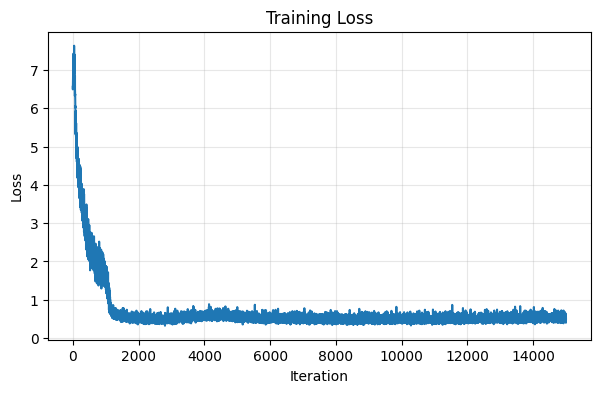

In [345]:
# Instantiate model and optimizer
model = DummyModel(
    num_nodes=7, num_atom_types=5
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

TEMP = 1
NUM_ITERS = 15000

NUM_GEN = 100
    # Sample noise once but for multiple molecules
    # as the real molecules
    # This is the logic in sample noise above



loss_list = []
for iter in range(NUM_ITERS):

    pos_noise = torch.randn((NUM_GEN, 7, 3))
    pos_noise = pos_noise - pos_noise.mean(dim=1, keepdim=True)
        # We sample random noise as embedding for atom types
    type_noise = torch.randn((NUM_GEN, 7, 5))
    combined_noise = torch.cat([pos_noise, type_noise], dim=2).flatten(start_dim=1)

    optimizer.zero_grad()
    gen_mol = model(combined_noise)
    gen_mol = gen_mol.reshape(NUM_GEN, 7, -1)
    gen_pos, gen_types = torch.split(gen_mol, [3, 5], dim=-1)
    gen_pos = gen_pos - gen_pos.mean(dim=1, keepdim=True)

    gen_types_prob = F.softmax(gen_types, dim=-1)
    gen_types_sphere = probs_to_sphere(gen_types_prob, eps=1e-8)

    loss, pos_distance, types_distance = compute_aligning_drift_loss(gen_pos, real_positions, gen_types_sphere, real_types)

    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")
        print("euclidean distance: ", pos_distance.mean())
        print("spherical_distance: ", types_distance.mean())

plot_loss(loss_list)

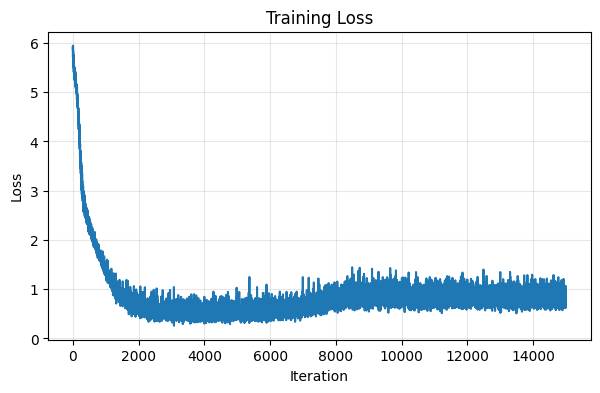

In [324]:
%matplotlib inline
plot_loss(loss_list)

tensor([[1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 3., 0., 0., 0., 0.],
        [1., 1., 3., 0., 0., 0., 0.],
        [3., 1., 1., 2., 0., 0., 0.],
        [2., 1., 1., 1., 2., 0., 0.],
        [3., 1., 1., 2., 2., 0., 0.],
        [3., 1., 2., 1., 2., 0., 0.],
        [3., 1., 2., 2., 1., 0., 0.],
        [3., 2., 1., 1., 2., 0., 0.],
        [3., 1., 1., 1., 1., 2., 0.],
        [3., 1., 1., 3., 1., 2., 0.],
        [1., 1., 1., 1., 1., 2., 0.],
        [3., 1., 1., 1., 1., 2., 0.],
        [3., 1., 2., 2., 2., 3., 0.],
        [3., 1., 3., 1., 2., 3., 0.],
        [3., 1., 2., 3., 2., 2., 0.],
        [4., 1., 4., 4., 1., 1., 0.],
        [4., 1., 4., 4., 1., 3., 0.],
        [2., 1., 1., 2., 3., 2., 2.],
        [3., 1., 2., 2., 3., 2., 2.]])
tensor([[3., 1., 1., 1., 1., 2., 0.],
        [3., 1., 1., 2., 1., 0., 0.],
        [3., 1., 1., 2., 1., 2., 0.],
        [3., 1., 2., 2., 2., 0., 0.],
        [3., 1., 2., 1., 1., 2., 0.],
        [3., 1., 1., 2., 1., 0., 0.],
        [3.

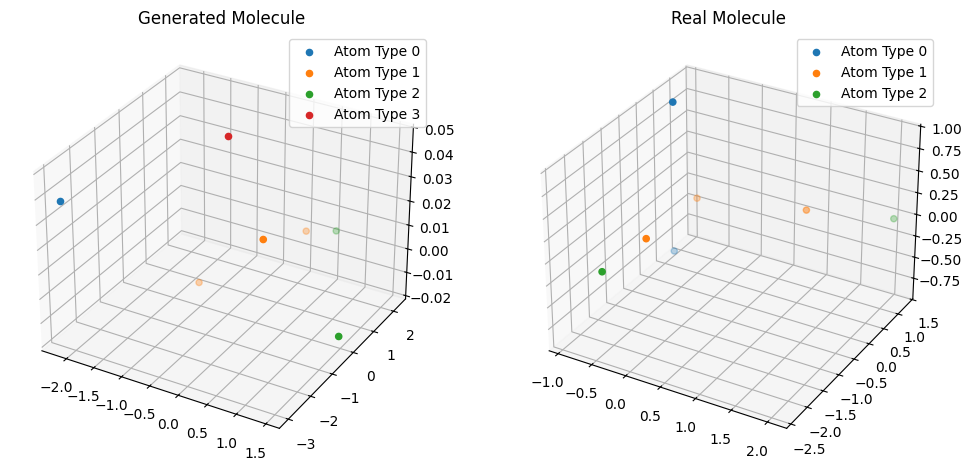

In [347]:
gen_mol = model(combined_noise)
gen_mol = gen_mol.reshape(NUM_GEN, 7, -1)
gen_pos, gen_types = torch.split(gen_mol, [3, 5], dim=-1)
gen_types_prob = F.softmax(gen_types, dim=-1)
gen_types_sphere = probs_to_sphere(gen_types_prob, eps=1e-8)
gen_types_prob = sphere_to_probs(gen_types_sphere, eps=1e-8)

gen_types_argmax = gen_types_prob.argmax(dim=-1).float()
real_types_argmax = real_types.argmax(dim=-1).float()

print(real_types_argmax)
print(gen_types_argmax)

INDEX_GEN_MOL = 4

visualize_both_molecules_with_atom_types(
    gen_pos,
    gen_types_argmax,
    real_positions,
    real_types_argmax,
    INDEX_GEN_MOL,
)

In [335]:

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent ))

from model.mol_utils.validity import batch_to_validity
from model.mol_utils.stability import batch_to_stability, heavy_atom_counts

import torch
import numpy as np

def evaluate_generated_molecules(
    gen_pos: torch.Tensor,
    gen_types: torch.Tensor,
    batch_vec: torch.Tensor | None = None,
):
    # If gen_types are probabilities/logits/sphere vectors: [N_mol, N_atoms, N_types]
    # convert to hard atom labels: [N_mol, N_atoms]
    if gen_types.dim() == 3:
        a_hard = gen_types.argmax(dim=-1).float()
    else:
        a_hard = gen_types.float()

    # If batched molecules: [N_mol, N_atoms, 3] -> [N_mol * N_atoms, 3]
    if gen_pos.dim() == 3:
        num_mol, num_atoms, _ = gen_pos.shape

        gen_pos_flat = gen_pos.reshape(num_mol * num_atoms, 3)
        a_hard_flat = a_hard.reshape(num_mol * num_atoms)

        if batch_vec is None:
            batch_vec = torch.arange(num_mol, device=gen_pos.device).repeat_interleave(num_atoms)
    else:
        gen_pos_flat = gen_pos
        a_hard_flat = a_hard

        if batch_vec is None:
            raise ValueError("batch_vec is required when gen_pos is already flattened.")

    results = batch_to_validity(
        gen_pos_flat.detach().cpu(),
        a_hard_flat.detach().cpu(),
        batch_vec.detach().cpu(),
    )

    heavy = heavy_atom_counts(
        a_hard_flat.detach().cpu(),
        batch_vec.detach().cpu(),
    )

    atom_stable_frac, mol_stable_frac = batch_to_stability(
        gen_pos_flat.detach().cpu(),
        a_hard_flat.detach().cpu(),
        batch_vec.detach().cpu(),
    )

    n_total = len(results)
    n_valid = sum(1 for ok, _ in results if ok)
    valid_ids = [ident for ok, ident in results if ok and ident is not None]

    uniqueness = len(set(valid_ids)) / len(valid_ids) if valid_ids else 0.0
    validity = n_valid / n_total if n_total > 0 else 0.0
    heavy_mean = float(np.mean(heavy)) if heavy else 0.0

    print(f"Validity: {validity:.4f}, Uniqueness: {uniqueness:.4f}, Mean Heavy Atoms: {heavy_mean:.2f}")
    print(f"Atom Stability Fraction: {atom_stable_frac:.4f}, Molecule Stability Fraction: {mol_stable_frac:.4f}")

In [348]:
evaluate_generated_molecules(gen_pos, gen_types_prob)

Validity: 0.1700, Uniqueness: 0.9412, Mean Heavy Atoms: 5.51
Atom Stability Fraction: 0.3729, Molecule Stability Fraction: 0.0100
